# Task 2.3 양자 상태 시각화하기

**Overview:** 이 노트북은 양자 상태를 시각화하는 방법을 다룹니다.

Qiskit에서 양자 상태는 Bloch multivector와 Q-sphere로 표현할 수 있습니다. 이러한 시각화 방법들을 활용하면 여러 큐빗들의 상태와 속성을 직관적으로 이해할 수 있습니다.

In [2]:
# Setup: Import necessary libraries
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector,DensityMatrix
import numpy as np


print("Libraries imported successfully.")

Libraries imported successfully.


## Objective 1: Bloch Multivector 시각화

`plot_bloch_multivector` 함수는 양자 시스템에서 각 큐비트의 상태를 나타내는 블로흐 구를 보여줍니다. 각각의 구에는 해당 큐비트의 (X, Y, Z) 파울리 측정의 기댓값이 보이게 됩니다.

이 방법은 큐비트가 많은 시스템에서 각 큐비트의 상태를 확인하는 가장 효과적인 방법입니다. 하지만, 큐빗들 사이에 존재하는 얽힘이나 그로 인한 위상차는 블로흐 구에 나타나지 않습니다. 따라서 이 표현법의 주 용도는 특정 양자 게이트가 각각의 큐비트에 어떻게 작용하는지 분석하는 것입니다.

Statevector: Statevector([ 0.5+0.j,  0.5+0.j, -0.5+0.j, -0.5+0.j],
            dims=(2, 2))


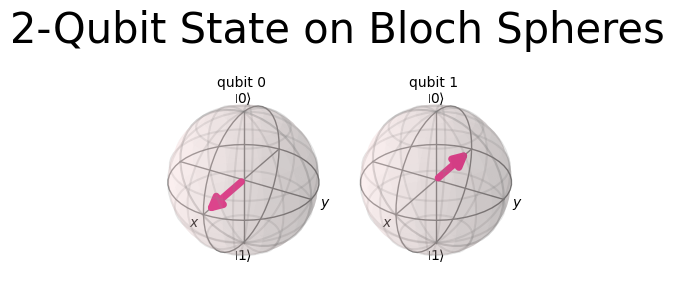

In [7]:
from qiskit.visualization import plot_bloch_multivector

# Create a simple 2-qubit circuit
qc = QuantumCircuit(2)
qc.h(0)    # Apply Hadamard to qubit 0: creates superposition |+⟩ = (|0⟩ + |1⟩)/√2
qc.x(1)
qc.h(1)    

# Get the statevector representing the quantum state
state = Statevector(qc)
print("Statevector:", state)
 
# Visualize each qubit on its own Bloch sphere
plot_bloch_multivector(state, title="2-Qubit State on Bloch Spheres",figsize=(2,2),title_font_size=30)

### 밀도 행렬과 큐빗 역순 정렬을 활용한 Bloch Multivector

밀도 행렬은 양자 상태가 통계적으로 분포하는 혼합 상태(mixed state)를 표현할 수 있습니다. `reverse_bits` 옵션을 활용하면 도식 상의 큐비트의 정렬 순서를 뒤집을 수 있습니다.

Density matrix shape: 8


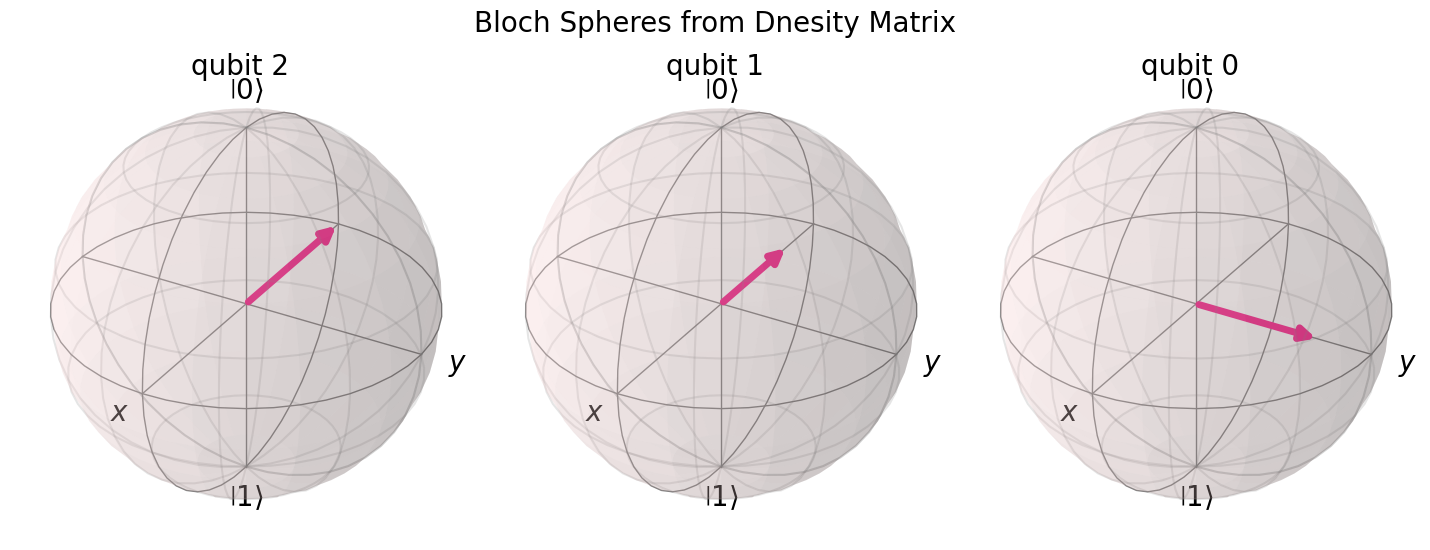

In [ ]:
# Create a more complex 3-qubit circuit
qc = QuantumCircuit(3)
qc.h([0, 1,2])    # Hadamard on all qubits: creates |+⟩ ⊗ |+⟩ ⊗ |+⟩ 
qc.t(1)         # T gate on qubit 1: adds π/4 phase (rotation around Z-axis)
qc.s(0)         # S gate on qubit 0: adds π/2 phase (rotation around Z-axis)
qc.z(2)         # Z gate on qubit 2
qc.cx(0, 1)     # CNOT gate: creates entanglement between qubits
qc.cx(1, 2)     # CNOT gate: creates entanglement between qubits
 
# Use DensityMatrix instead of Statevector
# Density matrices can represent both pure and mixed states
matrix = DensityMatrix(qc)
print("Density matrix shape:", matrix.dim)
 
# Visualize with reversed bit order and custom title and font size
plot_bloch_multivector(matrix, 
                     title='Bloch Spheres from Dnesity Matrix', 
                     reverse_bits=True,
                     font_size=20)

## Objective 2: Q-Sphere 시각화

Q-sphere를 활용하면 많은 큐빗이 존재하는 시스템에서 모든 계산 기저를 구면 상으로 매핑함으로써 양자 상태를 간단하게 표현할 수 있습니다. 각각의 기저 상태가 갖는 진폭과 위상은 크기와 색깔, 방향으로 표현됩니다.

이 방법은 다중 큐빗 시스템의 양자 상태를 완전히 표현하고 싶을 때에 가장 효과적입니다. 이 방법에서는 큐비트 사이의 얽힘과 위상 차이도 표현할 수 있습니다. 그러나, 큐비트의 개수가 증가하면 표현해야 하는 계산 기저의 숫자가 기하급수적으로 늘어나기 때문에 도식을 그리고 읽기가 어려워집니다.

Final statevector:
Statevector([ 0.        +0.j, -0.70710678+0.j,  0.70710678+0.j,
              0.        +0.j],
            dims=(2, 2))


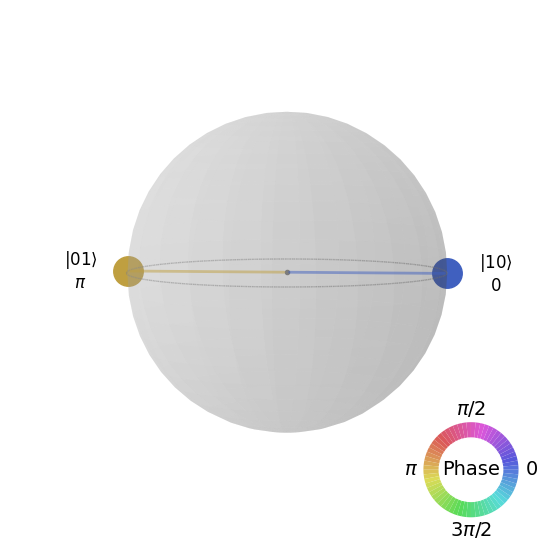

In [5]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_state_qsphere
 
# Create a circuit that produces an interesting quantum state
qc = QuantumCircuit(2)
qc.h(0)        # Hadamard: creates superposition
qc.z(0)        # Z gate: adds phase flip to |1⟩ component
qc.x(1)        # X gate: |0⟩ → |1⟩
qc.cx(0, 1)    # CNOT: creates controlled operation
 
# Get the final state
state = Statevector(qc)
print("Final statevector:")
print(state)
 
# Visualize on Q-sphere with enhanced options
plot_state_qsphere(state, 
                  use_degrees=False,           # Show phases in radians
                  show_state_phases=True,     # Display phase arrows
                  show_state_labels =True)

# - Points on sphere represent computational basis states |00⟩, |01⟩, |10⟩, |11⟩
# - Points size shows magnitude of each amplitude
# - Colors indicate different phase regions

### 밀도 행렬과 회전 게이트를 활용한 Q-Sphere

이 예시는 사용자가 정의한 회전과 밀도 행렬을 활용해 만든 더 복잡한 상태를 Q-sphere로 시각화하는 방법을 보여줍니다.

Circuit creates a complex entangled state with custom rotations


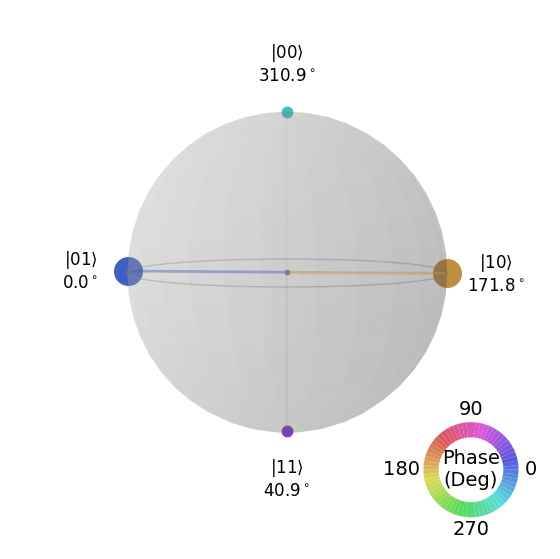

In [6]:
from qiskit.visualization import plot_state_qsphere

# - Multiple basis states have non-zero amplitudes
# - Phase colors show complex phases introduced by rotation gates
# - Degrees make phase values more intuitive (0° = +1, 180° = -1, etc.)

# Create a circuit with various quantum gates
qc = QuantumCircuit(2)
qc.h([0, 1])        # Hadamard on both: creates equal superposition
qc.cz(0, 1)         # Controlled-Z: entangles qubits with phase kick
qc.ry(np.pi/3, 0)   # Rotation around Y-axis by 60° on qubit 0
qc.rx(np.pi/6, 1)   # Rotation around X-axis by 30° on qubit 1
qc.z(1)             # Z gate on qubit 1: global phase shift
 
# Use density matrix representation
matrix = DensityMatrix(qc)
print("Circuit creates a complex entangled state with custom rotations")
 
# Enhanced Q-sphere visualization
plot_state_qsphere(matrix,
     show_state_phases=True,    # Show phase arrows for each basis state
     use_degrees=True,          # Display phases in degrees (0-360°)
     show_state_labels =True)

---
## 요약
---

이 노트북에서는 다음의 내용을 다루었습니다:

## 양자 상태의 시각화:

양자 상태는 다음과 같은 방법으로 시각화할 수 있습니다:
 
1. **Bloch multivector**: 양자 시스템에 존재하는 각 큐비트의 상태를 알아보는데 사용하는 방법.
2. **Qsphere**  양자 시스템의 전체 상태를 알아보는데 사용하는 방법.


---

## 연습 문제

**1) When visualizing a 2-qubit Bell state ∣Φ+⟩=(∣00⟩+∣11⟩)/√2 , what will `plot_bloch_multivector` show?**

A) 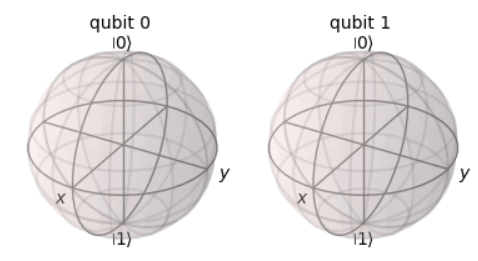

B) 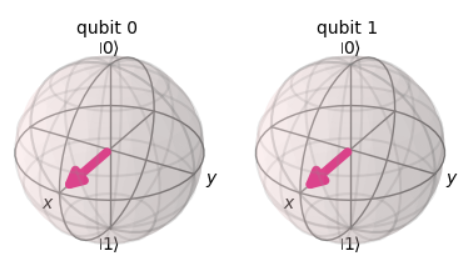

C) 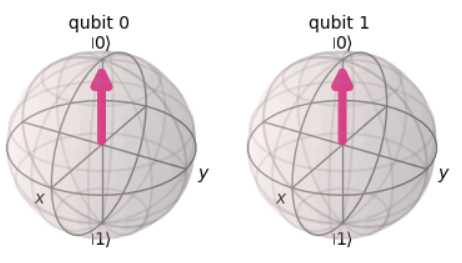 

   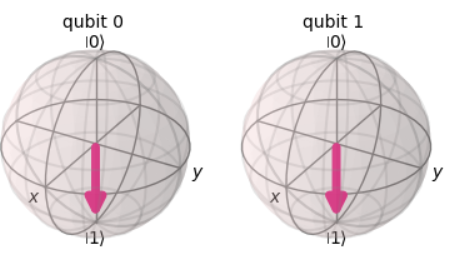



D) 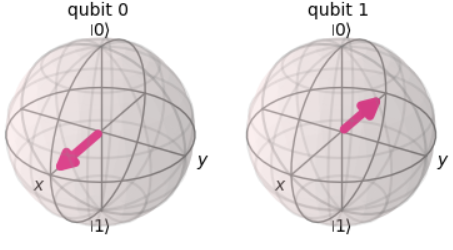


***정답:***
<Details>
<br/>
A) 모든 큐빗이 완전히 얽힌 상태이므로, 블로흐 벡터는 길이가 0인 벡터가 되어 보이지 않게 됩니다.
</Details>

---

**2) In the Q-sphere representation from `plot_state_qsphere`, how is propability amplitude of each computational basis amplitude visualized?**

A) By vertical height of the dot

B) By the radius of the dot

C) By color of the dot

D) By a text label next to the dot


***정답:***
<Details>
<br/>
B) 각 계산 기저의 진폭은 점의 크기, 즉 반지름으로 나타납니다. <br/>
점의 색깔은 해당 기저의 위상을 표현하며, 점 옆의 텍스트는 대응하는 계산 기저와 위상을 수치로 표현합니다. 점의 높이는 해당 계산 기저의 해밍 가중치와 관련이 있습니다.
</Details>